<a href="https://colab.research.google.com/github/tirumanivaishnavivaishu-bit/Magnetic-field-energy-form-/blob/main/Magnetic_field_energy_form.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Enter inductances in Henry
L1 = 2.0
L2 = 1.0

# Coupling coefficient: 0 <= k <= 1
k = 0.5

# Currents in Ampere
I1 = 2.0
I2 = 1.0

# Mutual inductance
M = k * np.sqrt(L1 * L2)

print("L1 =", L1, "H")
print("L2 =", L2, "H")
print("k  =", k)
print("M  =", round(M, 4), "H")

L1 = 2.0 H
L2 = 1.0 H
k  = 0.5
M  = 0.7071 H


In [3]:
# Inductance matrix
A = np.array([
    [L1, M],
    [M, L2]
])

# Current vector
I = np.array([I1, I2])

# Magnetic energy: W = 1/2 I^T A I
W = 0.5 * I.T @ A @ I

# Eigenvalues
eigenvalues = np.linalg.eigvalsh(A)

print("Inductance matrix:")
print(A)

print("\nCurrent vector:")
print(I)

print("\nEnergy calculation:")
print("W = 1/2 * I^T A I")
print("W =", round(W, 6), "J")

print("\nEigenvalues:")
print(eigenvalues)

if np.all(eigenvalues > 0):
    print("\nResult: A is POSITIVE DEFINITE.")
else:
    print("\nResult: A is NOT positive definite.")

Inductance matrix:
[[2.         0.70710678]
 [0.70710678 1.        ]]

Current vector:
[2. 1.]

Energy calculation:
W = 1/2 * I^T A I
W = 5.914214 J

Eigenvalues:
[0.6339746 2.3660254]

Result: A is POSITIVE DEFINITE.


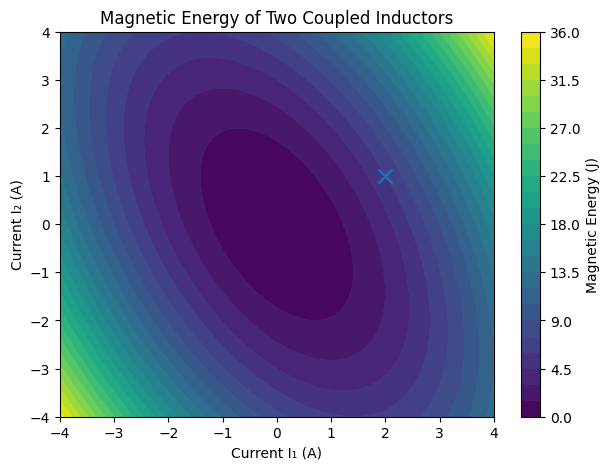

In [4]:
# Create a grid of possible currents
i1_values = np.linspace(-4, 4, 100)
i2_values = np.linspace(-4, 4, 100)

I1_grid, I2_grid = np.meshgrid(i1_values, i2_values)

# Energy at every point
W_grid = 0.5 * (
    L1 * I1_grid**2
    + L2 * I2_grid**2
    + 2 * M * I1_grid * I2_grid
)

plt.figure(figsize=(7, 5))

contour = plt.contourf(
    I1_grid, I2_grid, W_grid, levels=30
)

plt.colorbar(contour, label="Magnetic Energy (J)")
plt.xlabel("Current I₁ (A)")
plt.ylabel("Current I₂ (A)")
plt.title("Magnetic Energy of Two Coupled Inductors")

plt.scatter(I1, I2, marker="x", s=100)

plt.show()